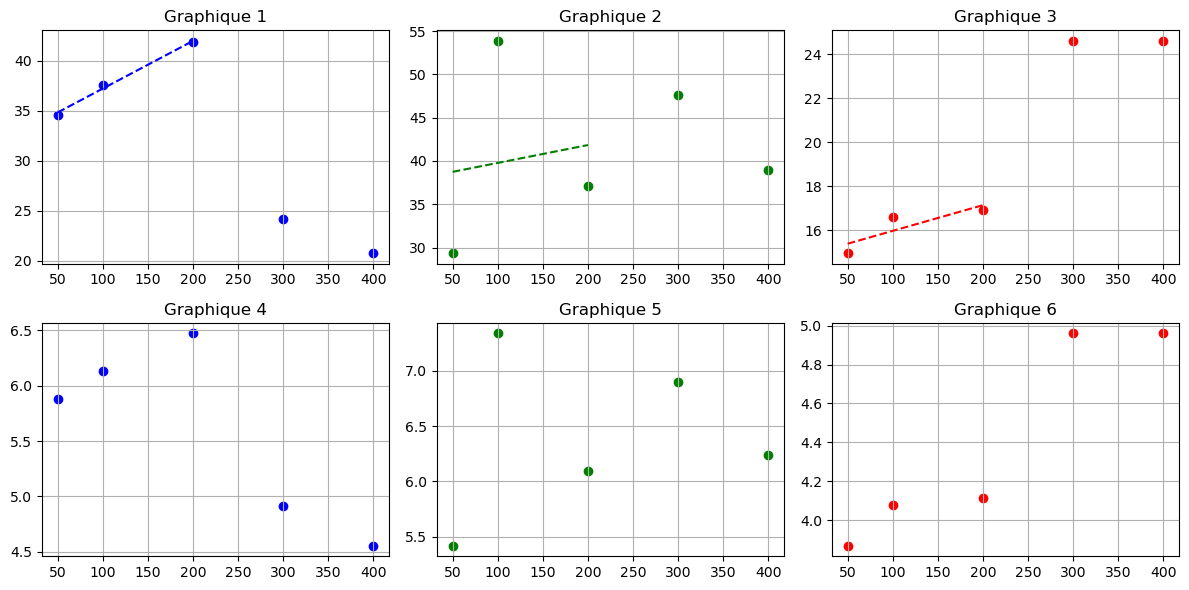

In [10]:
import numpy as np
import matplotlib.pyplot as plt

amplitude = np.array([50,100,200,300,400]) # en mV

# -- liste des batch --

batch_155 = np.array([34.571,37.612,41.861,24.146,20.745])
sqrt_155 = np.array([5.879,6.132,6.472,4.914,4.555])

batch_310 = np.array([29.347,53.855,37.138,47.633,38.918])
sqrt_310 = np.array([5.417,7.340,6.096,6.902,6.237])

batch_465 = np.array([14.965,16.623,16.93,24.601,24.601])
sqrt_465 = np.array([3.868,4.077,4.115,4.960,4.960])

# -- regression linéaire --
#fit_155 = np.polyfit(amplitude, batch_155, 1)
fit_155 = np.polyfit(amplitude[0:3], batch_155[0:3], 1)
a_155 = fit_155[0]
b_155 = fit_155[1]

fit_310 = np.polyfit(amplitude[0:3], batch_310[0:3], 1)
a_310 = fit_310[0]
b_310 = fit_310[1]

fit_465 = np.polyfit(amplitude[0:3], batch_465[0:3], 1)
a_465 = fit_465[0]
b_465 = fit_465[1]

# -- affichages des graphiques --
plt.figure(figsize=(12, 6)) 

plt.subplot(2, 3, 1)
plt.scatter(amplitude, batch_155, label='Batch 155', color='blue')
plt.plot(amplitude[0:3], a_155 * amplitude[0:3] + b_155, color='blue', linestyle='--', label='Régression Batch 155')
plt.title("Graphique 1")
plt.grid(True)

plt.subplot(2, 3, 2)
plt.scatter(amplitude, batch_310, label='Batch 310', color='green')
plt.plot(amplitude[0:3], a_310 * amplitude[0:3] + b_310, color='green', linestyle='--', label='Régression Batch 310')
plt.title("Graphique 2")
plt.grid(True)

plt.subplot(2, 3, 3)
plt.scatter(amplitude, batch_465, label='Batch 465', color='red')
plt.plot(amplitude[0:3], a_465 * amplitude[0:3] + b_465, color='red', linestyle='--', label='Régression Batch 465')
plt.title("Graphique 3")
plt.grid(True)

plt.subplot(2, 3, 4)
plt.scatter(amplitude, sqrt_155, label='Batch 155', color='blue')
plt.title("Graphique 4")
plt.grid(True)

plt.subplot(2, 3, 5)
plt.scatter(amplitude, sqrt_310, label='Batch 310', color='green')
plt.title("Graphique 5")
plt.grid(True)

plt.subplot(2, 3, 6)
plt.scatter(amplitude, sqrt_465, label='Batch 465', color='red')
plt.title("Graphique 6")
plt.grid(True)

plt.tight_layout() 

plt.show()

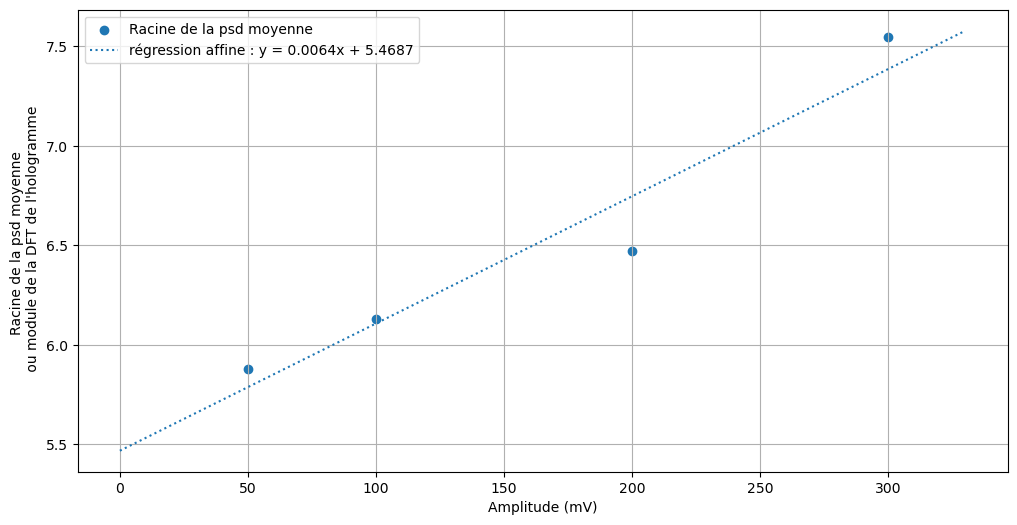

In [49]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

#fonctions de régression
def linear(x, a):
    return a*x
popt, pcov = curve_fit(linear, amplitude, batch_155)
a = popt[0]

def affine(x, b,c):
    return(b*x+c)

#Données
#mesures pour amplitudes faites au GBF de 50mV à 1V
Batch_155 = np.array([34.571, 37.612, 41.861, 56.985])
batch_155 = np.sqrt(Batch_155)
amplitude = np.array([50, 100, 200, 300])  # même nombre de points

#Régressions
popt, pcov = curve_fit(linear, amplitude, batch_155)
a = popt[0]

popt2,pcov2 = curve_fit(affine, amplitude, batch_155)
b,c = popt2

# Tracé

xfit = np.linspace(0, amplitude.max()*1.1, 100)

plt.figure(figsize=(12, 6)) 
plt.scatter(amplitude, batch_155, label="Racine de la psd moyenne")

#plt.plot(xfit, linear(xfit, a),linestyle=':',label=f"régression linéaire : y = {a:.4f}x")
plt.plot(xfit, affine(xfit,b,c),linestyle=':',label=f"régression affine : y = {b:.4f}x + {c:.4f}")

plt.grid(True)
plt.xlabel("Amplitude (mV)")
plt.ylabel("Racine de la psd moyenne \n ou module de la DFT de l'hologramme")
plt.legend()
plt.show()

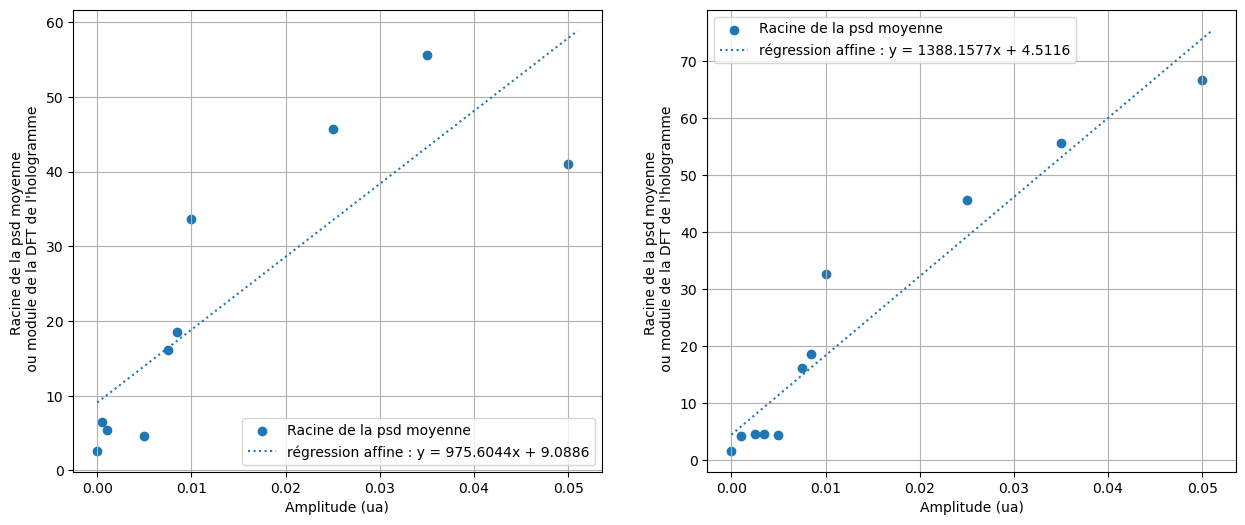

In [13]:
#première série de mesure, les amplitudes sont en uA selon phyfox
#on a posé le téléphone à 4cm de la lame
#la fréquence émise est de 979,6Hz c'est la 5eme lame (plus grande à plus petite)
#on n'avait pas vu qu'il y a une deuxième fréquence émise inchangée pour toutes les mesures de cette série

#ici les piques se trouvent principalement dans les batchs 285-286 au lieu de 281
Amplitude_ua_set1 = np.array([0.05,0.035,0.025,0.01,0.0085,0.0075,0.005,0.001,0.0005,0])
psd_mean_ua1 = np.array([1684.5,3092,2086.9,1132.6,344.78,259.78,21.5,29.75,42.274,7])
sqrt_psd_mean_ua1 = np.sqrt(psd_mean_ua1)

#Mesures sans la deuxièmes fréquences émises et avec plus de silence (il y avait un deuxième ordinateur allumé dans la pièce auparavant)
Amplitude_ua_set2 = np.array([0.05,0.035,0.025,0.01,0.0085,0.0075,0.005,0.0035,0.0025,0.001,0])
psd_mean_ua2 = np.array([4453.1,3092,2086.9,1070.9,344.78,259.78,19.99,21.5,21.5,17.618,2.9])
sqrt_psd_mean_ua2 = np.sqrt(psd_mean_ua2)

#on a supprimé le point en 0.1 car il était trop éloigné
#mais peut être qu'on peut chercher s'il y a une rupture ?




#paramètres regression
popt_ua1,pcov_ua1 = curve_fit(affine, Amplitude_ua_set1, sqrt_psd_mean_ua1)
a_ua1,b_ua1 = popt_ua1

popt_ua2,pcov_ua2 = curve_fit(affine, Amplitude_ua_set2, sqrt_psd_mean_ua2)
a_ua2,b_ua2 = popt_ua2

#Tracé

xfit = np.linspace(0, 0.051, 100)
plt.figure(figsize=(15, 6)) 

plt.subplot(1, 2, 1)

plt.scatter(Amplitude_ua_set1, sqrt_psd_mean_ua1, label="Racine de la psd moyenne")
plt.plot(xfit, affine(xfit, a_ua1, b_ua1),linestyle=':',label=f"régression affine : y = {a_ua1:.4f}x + {b_ua1:.4f}")

plt.grid(True)
plt.xlabel("Amplitude (ua)")
plt.ylabel("Racine de la psd moyenne \n ou module de la DFT de l'hologramme")
plt.legend()


plt.subplot(1, 2, 2)

plt.scatter(Amplitude_ua_set2, sqrt_psd_mean_ua2, label="Racine de la psd moyenne")
plt.plot(xfit, affine(xfit, a_ua2, b_ua2),linestyle=':',label=f"régression affine : y = {a_ua2:.4f}x + {b_ua2:.4f}")

plt.grid(True)
plt.xlabel("Amplitude (ua)")
plt.ylabel("Racine de la psd moyenne \n ou module de la DFT de l'hologramme")
plt.legend()

plt.show()

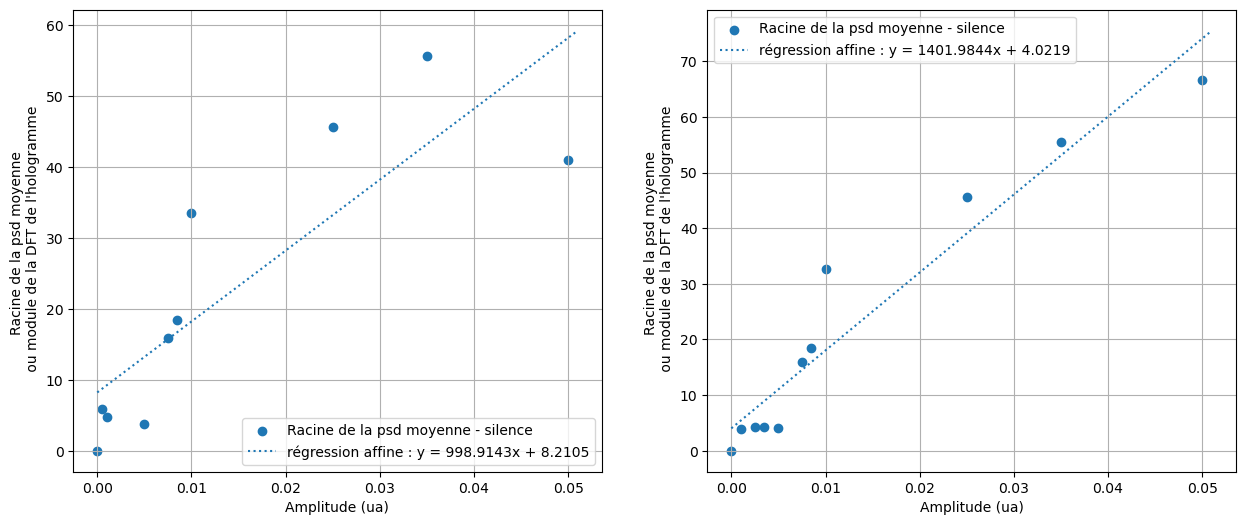

In [15]:
psd_mean_ua1_s = psd_mean_ua1-7
sqrt_psd_mean_ua1_s = np.sqrt(psd_mean_ua1_s)
psd_mean_ua2_s = psd_mean_ua2-2.9
sqrt_psd_mean_ua2_s = np.sqrt(psd_mean_ua2_s)



popt_ua1s,pcov_ua1s = curve_fit(affine, Amplitude_ua_set1, sqrt_psd_mean_ua1_s)
a_ua1s,b_ua1s = popt_ua1s

popt_ua2s,pcov_ua2s = curve_fit(affine, Amplitude_ua_set2, sqrt_psd_mean_ua2_s)
a_ua2s,b_ua2s = popt_ua2s

xfit = np.linspace(0, 0.051, 100)
plt.figure(figsize=(15, 6)) 

plt.subplot(1, 2, 1)
plt.scatter(Amplitude_ua_set1, sqrt_psd_mean_ua1_s, label="Racine de la psd moyenne - silence")
plt.plot(xfit, affine(xfit, a_ua1s, b_ua1s),linestyle=':',label=f"régression affine : y = {a_ua1s:.4f}x + {b_ua1s:.4f}")
plt.grid(True)
plt.xlabel("Amplitude (ua)")
plt.ylabel("Racine de la psd moyenne \n ou module de la DFT de l'hologramme")
plt.legend()


plt.subplot(1, 2, 2)
plt.scatter(Amplitude_ua_set2, sqrt_psd_mean_ua2_s, label="Racine de la psd moyenne - silence")
plt.plot(xfit, affine(xfit, a_ua2s, b_ua2s),linestyle=':',label=f"régression affine : y = {a_ua2s:.4f}x + {b_ua2s:.4f}")
plt.grid(True)
plt.xlabel("Amplitude (ua)")
plt.ylabel("Racine de la psd moyenne \n ou module de la DFT de l'hologramme")
plt.legend()

plt.show()

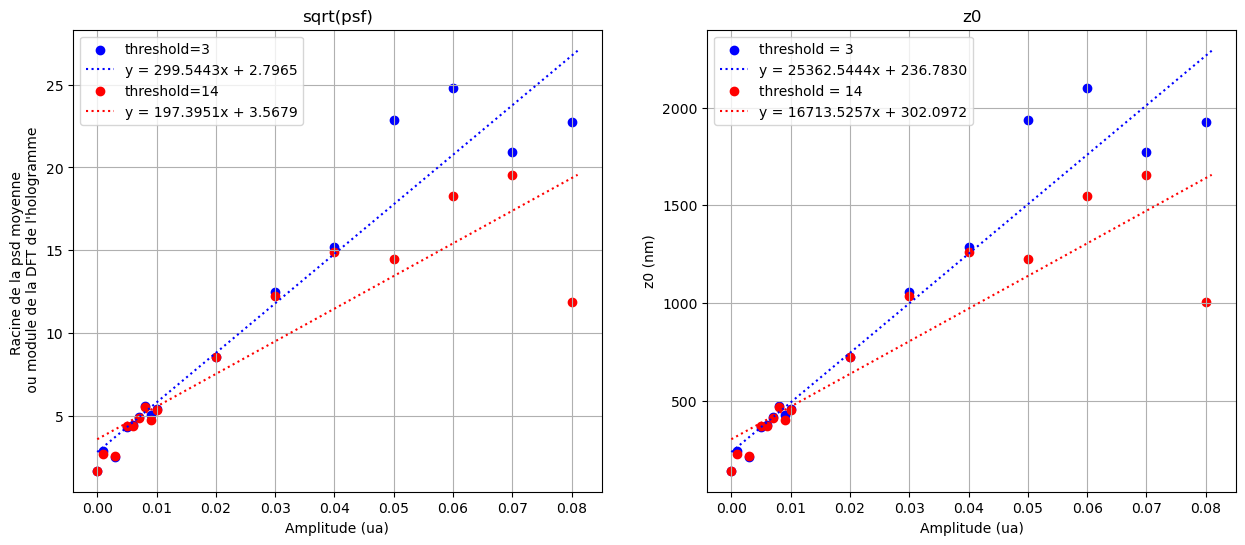

In [24]:
# les 16 points avec threshold à 3 :
Lambda = 532 #nm

Ampli = np.array([0.08,0.07,0.06,0.05,0.04,0.03,0.02,0.01,0.009,0.008,0.007,0.006,0.005,0.003,0.001,0]) #unité arbitraire
psd_3thrs = np.array([517.04,437.04,616.53,524.26,231.03,154.87,72.66,29.24,25.334,31.098,23.983,19.739,18.794,6.3084,8.1166,2.7896])
sqrt_3thrs = np.sqrt(psd_3thrs)
z0_3thrs = Lambda * sqrt_3thrs/(2*np.pi)

psd_14thrs = np.array([140.93,381.54,333.52,209.91,221.56,150.07,72.675,28.181,22.573,30.493,23.34,19.215,18.952,6.3704,7.2602,2.768])
sqrt_14thrs = np.sqrt(psd_14thrs)
z0_14thrs = Lambda * sqrt_14thrs/(2*np.pi)



popt_ua1s,pcov_ua1s = curve_fit(affine, Ampli, sqrt_3thrs)
a_ua1s,b_ua1s = popt_ua1s

popt_ua2s,pcov_ua2s = curve_fit(affine, Ampli, sqrt_14thrs)
a_ua2s,b_ua2s = popt_ua2s

xfit = np.linspace(0, 0.081, 100)
plt.figure(figsize=(15, 6)) 

plt.subplot(1, 2, 1)
plt.scatter(Ampli, sqrt_3thrs, color='b',label="threshold=3")
plt.plot(xfit, affine(xfit, a_ua1s, b_ua1s),color ='b',linestyle=':',label=f"y = {a_ua1s:.4f}x + {b_ua1s:.4f}")

plt.scatter(Ampli, sqrt_14thrs, color='r',label="threshold=14")
plt.plot(xfit, affine(xfit, a_ua2s, b_ua2s),color ='r',linestyle=':',label=f"y = {a_ua2s:.4f}x + {b_ua2s:.4f}")

plt.grid(True)
plt.xlabel("Amplitude (ua)")
plt.ylabel("Racine de la psd moyenne \n ou module de la DFT de l'hologramme")
plt.title("sqrt(psf)")
plt.legend()

popt_ua1s,pcov_ua1s = curve_fit(affine, Ampli, z0_3thrs)
a_ua1s,b_ua1s = popt_ua1s

popt_ua2s,pcov_ua2s = curve_fit(affine, Ampli, z0_14thrs)
a_ua2s,b_ua2s = popt_ua2s

plt.subplot(1, 2, 2)
plt.scatter(Ampli, z0_3thrs, color='b',label="threshold = 3")
plt.plot(xfit, affine(xfit, a_ua1s, b_ua1s),color ='b',linestyle=':',label=f"y = {a_ua1s:.4f}x + {b_ua1s:.4f}")

plt.scatter(Ampli, z0_14thrs, color='r',label="threshold = 14")
plt.plot(xfit, affine(xfit, a_ua2s, b_ua2s),color ='r',linestyle=':',label=f"y = {a_ua2s:.4f}x + {b_ua2s:.4f}")
plt.title('z0')
plt.grid(True)
plt.xlabel("Amplitude (ua)")
plt.ylabel("z0 (nm)")
plt.legend()

plt.show()

Text(0.5, 0, 'Fréquence (Hz)')

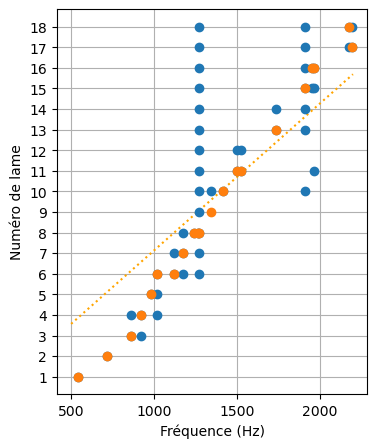

In [60]:
#graphique de la charactérisation harmonique de la lame

#la première lame est la plus petite
#la dix-huitième est la plus grande

#Données :

data_cara_harm = {
    540.4: [1],
    719.0: [2],
    862.5: [3,4],
    923.3: [3,4],
    979.6: [5],
    1015.5: [4,5,6],
    1121.4: [6,7],
    1172.5: [6,7,8],
    1241.4: [8],
    1264.22: [8],
    1272.0: [6,7,8,9,10,11,12,13,14,15,17,16,18],
    1343.2: [10],
    1418.0: [10],
    1500.0: [11,12],
    1523.0: [11,12],
    1738.8: [13,14],
    1911.0: [10,13,14,15,16,17,18],
    1952.0: [15,16],
    1967.0: [11,15,16],
    2174.5: [17,18],
    2196.5: [17,18],
    #3360.0: [17]
}

data_cara_harm_filtree = {
    540.4: [1],
    719.0: [2],
    862.5: [3],
    923.3: [4],
    979.6: [5],
    1015.5: [6],
    1121.4: [6],
    1172.5: [7],
    1241.4: [8],
    1264.22: [8],
    1272.0: [8],
    1343.2: [9],
    1418.0: [10],
    1500.0: [11],
    1523.0: [11],
    1738.8: [13],
    1911.0: [15],
    1952.0: [16],
    1967.0: [16],
    2174.5: [18],
    2196.5: [17],
    #3360.0: [17]
}

frq_harm_tt = []
lames_tt = []
frq_harm_flt = []
lames_flt = []

for f, liste_lames in data_cara_harm.items():
    frq_harm_tt.extend([f] * len(liste_lames))
    lames_tt.extend(liste_lames)
    
for f, liste_lames in data_cara_harm_filtree.items():
    frq_harm_flt.extend([f] * len(liste_lames))
    lames_flt.extend(liste_lames)
    
incertitude_frq_harm = np.array([0.4,2,0.4,0.4,0.4,0.4,0.4,0.4,0.4, 0.4,])

#Régression :
popt_harm,pcov_harm = curve_fit(linear, frq_harm_flt, lames_flt)
a_harm = popt_harm[0]
xfit_harm = np.linspace(500, 2200, 200)

#Tracé :
    
plt.figure(figsize=(4, 5)) 
plt.errorbar(frq_harm_tt, lames_tt, xerr=0.4, fmt ='o')
plt.errorbar(frq_harm_flt, lames_flt, xerr=0.4, fmt='o')

plt.plot(xfit_harm, linear(xfit_harm, a_harm),color ='orange',linestyle=':',label=f"y = {a_harm:.4f}x")

plt.grid(True)
plt.yticks(np.arange(1, 19))
plt.ylabel("Numéro de lame")
plt.xlabel("Fréquence (Hz)")